# Preprocessing Benchmark

O pré-processamento de áudio é uma etapa fundamental para preparar os dados brutos para o treinamento de modelos de Deep Learning. Neste projeto, a classe `AudioPreprocessor` realiza as seguintes operações sequenciais em cada clipe de áudio:

1.  **Conversão para Mono**: Se o áudio original for estéreo, ele é convertido para um único canal (mono).

2.  **Reamostragem (Resampling)**: O áudio é reamostrado para uma taxa de amostragem padrão (ex: 22050 Hz) para garantir consistência.

3.  **Zero Padding**: Clipes mais curtos que a duração alvo são preenchidos com zeros até atingirem o comprimento fixo necessário para a rede neural.

4. **Criação de channels**: Aplicação de 4 tipos de tratamento, para além da representação original. As primeiras duas são **delta** e **delta-delta**, representando conceptualmente o mesmo que as derivadas de 1a e 2a ordem do áudio, isto é, indicam o crescimento e a variação desse crescimento. As restantes duas são obtidas por **HPSS** (Harmonic-Percussive Source Separation), um algoritmo que separa a componente melódica do áudio da sua componente percursiva. Assim obtêve-se os channels  **hpss-melodic** e **hpss-percursive**.

5.  **Extração de Características**: Os 5 vetores de áudio são transformados numa representação espectral, nomeadamente usando **Log-Mel Spectrogram**.

## Análise preliminar

Apesar da implementação parecer sã, convêm realizar alguns testes para aferir a qualidade do pré-processamento. Assim, importamos a classe instanciando-a com os argumentos default.

In [4]:
from preprocessing import AudioPreprocessor
from soundata import initialize
from dataloader import Dataloader

# Inicializa o preprocessador de áudio com os parâmetros default
preprocessor = AudioPreprocessor(sample_rate=22050, to_mono=True)


# Inicializa o dataloader sem preprocessamento (para podermos aplicar manualmente)
# NOTA: Alterar para o caminho do dataset na sua máquina
dataset_path = r"E:\deep-learning-urban-sound-data\datasets"
dl = Dataloader(dataset_path)

Escolhamos então um áudio para comparar. Usamos abaixo um com label `gun_shot` para garantir que o Zero Padding é aplicado.

{0: 'air_conditioner', 1: 'car_horn', 2: 'children_playing', 3: 'dog_bark', 4: 'drilling', 5: 'engine_idling', 6: 'gun_shot', 7: 'jackhammer', 8: 'siren', 9: 'street_music'}
Extracted features shape: (64, 173)


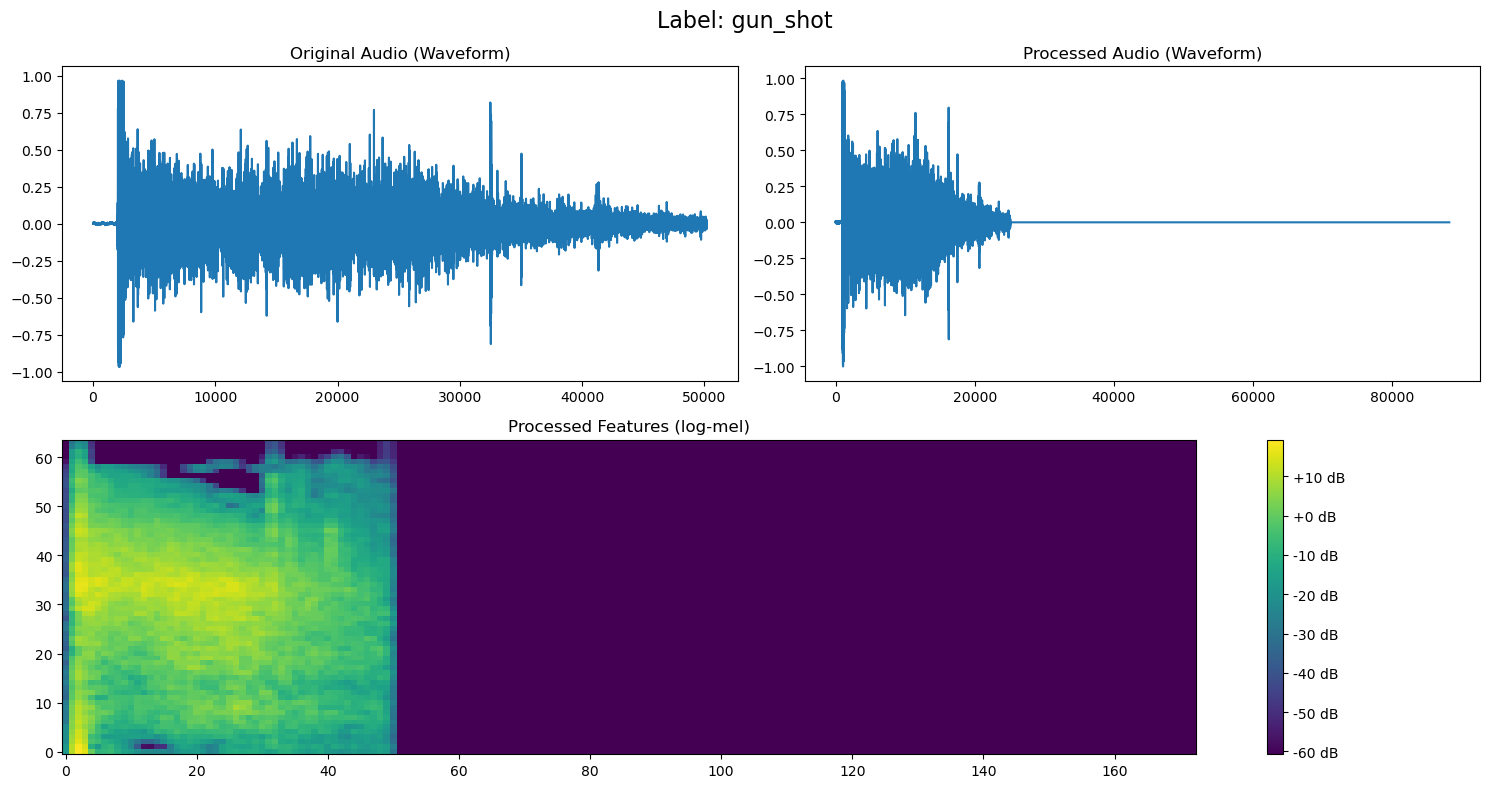

In [8]:
import matplotlib.pyplot as plt

def preview_preprocessing(class_id : int):
    """
    Função para visualizar o pré-processamento de um clipe de áudio do UrbanSound8K.
    """

    # Obter o primeiro clipe da label pretendida
    target_class_clips = [clip for clip in dl.all_clips.values() if clip.class_id == class_id]
    clip = target_class_clips[0]

    # Processar o clipe
    features = preprocessor.process_clip(clip)
    print(f"Extracted features shape: {features.shape}")

    # Obter o label do clipe
    label = clip.tags.labels[0] if clip.tags.labels else "Unknown"

    # Processar o áudio para obter a forma de onda processada (antes da extração de features)
    audio, original_sr = clip.audio
    audio_mono = preprocessor.monorize_audio(audio)
    audio_resampled = preprocessor.resample_audio(audio_mono, original_sr)
    audio_processed = preprocessor.zero_pad_audio(audio_resampled)
    plt.figure(figsize=(15, 8))
    plt.suptitle(f"Label: {label}", fontsize=16)
    
    # 1. Audio Original (Waveform)
    plt.subplot(2, 2, 1)
    plt.title("Original Audio (Waveform)")
    plt.plot(clip.audio[0]) # Plotando apenas o primeiro canal se for estéreo

    # 2. Audio Processado (Waveform)
    plt.subplot(2, 2, 2)
    plt.title("Processed Audio (Waveform)")
    plt.plot(audio_processed)
    
    # 3. Features (Log-Mel Spectrogram)
    plt.subplot(2, 1, 2)
    plt.title(f"Processed Features ({preprocessor.extraction_method})")
    plt.imshow(features, aspect='auto', origin='lower')
    plt.colorbar(format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

print(dl.get_label_mapping())
preview_preprocessing(class_id=6)

Assim, conseguimos ver que as fases 1, 2 e 3 do pré-processamento funcionou corretamente, mantendo a forma geral do audio e aplicando o Zero Padding como esperado. Tentemos para alguns outros labels.

Extracted features shape: (64, 173)


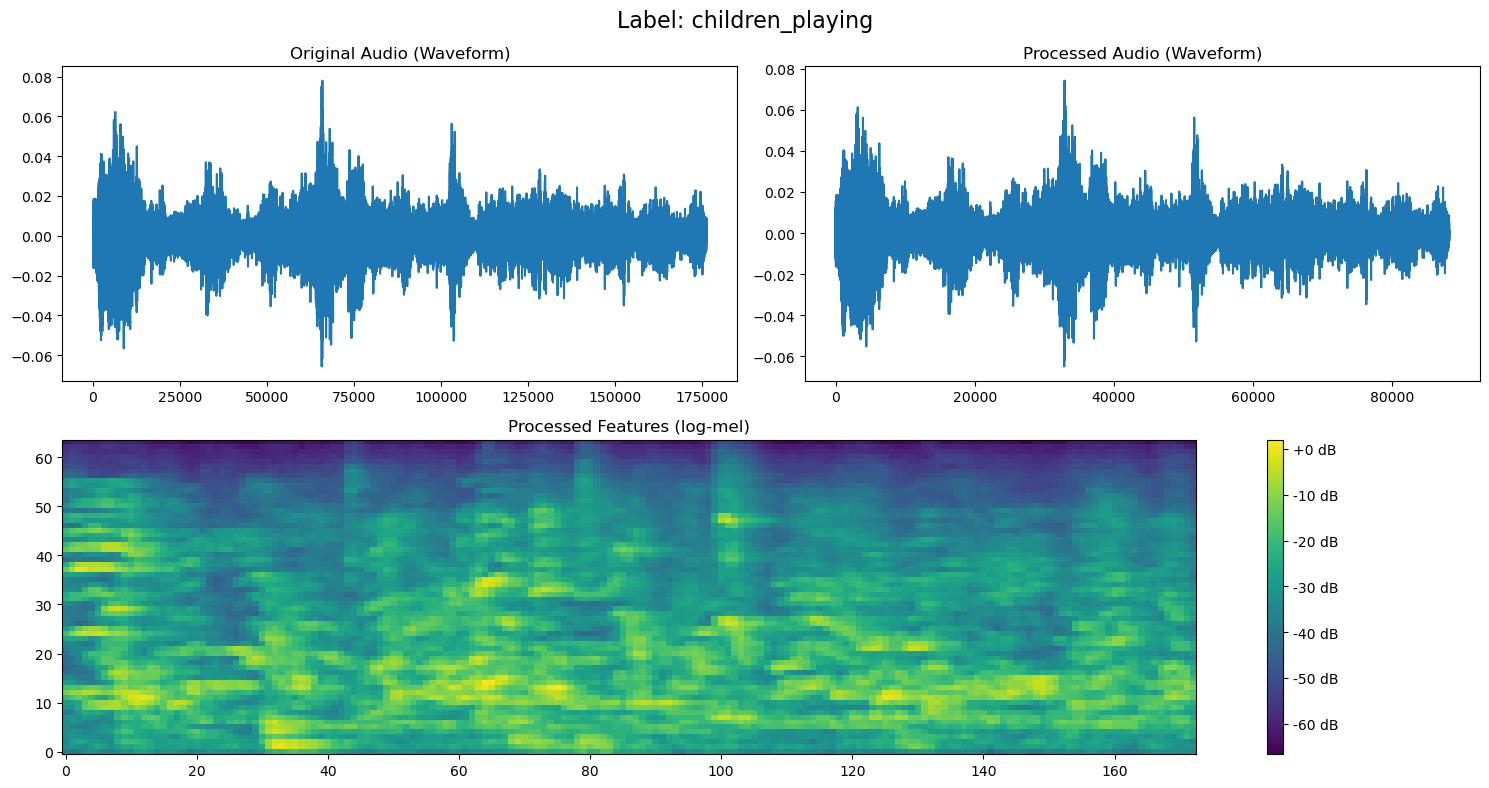

Extracted features shape: (64, 173)


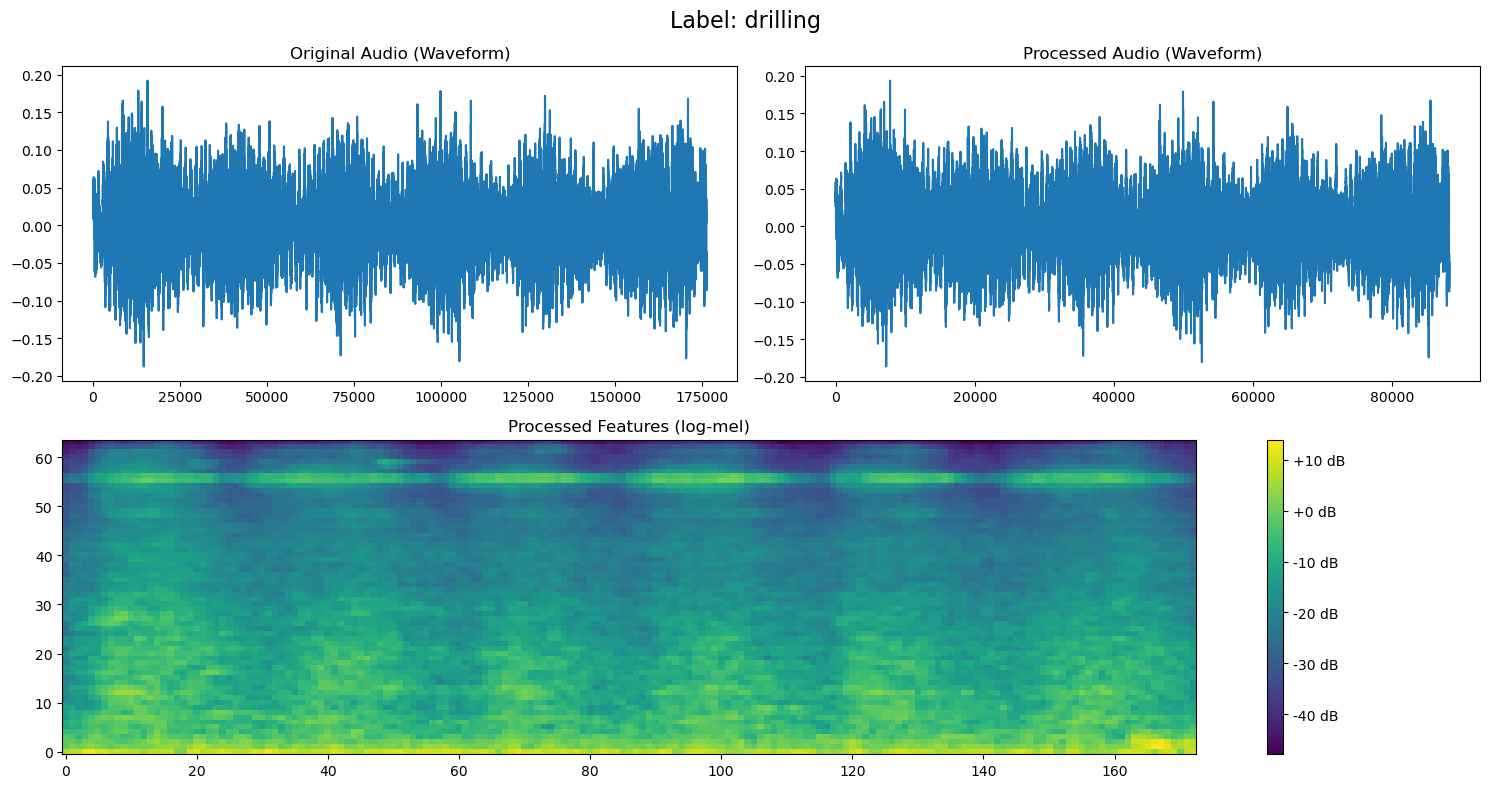

Extracted features shape: (64, 173)


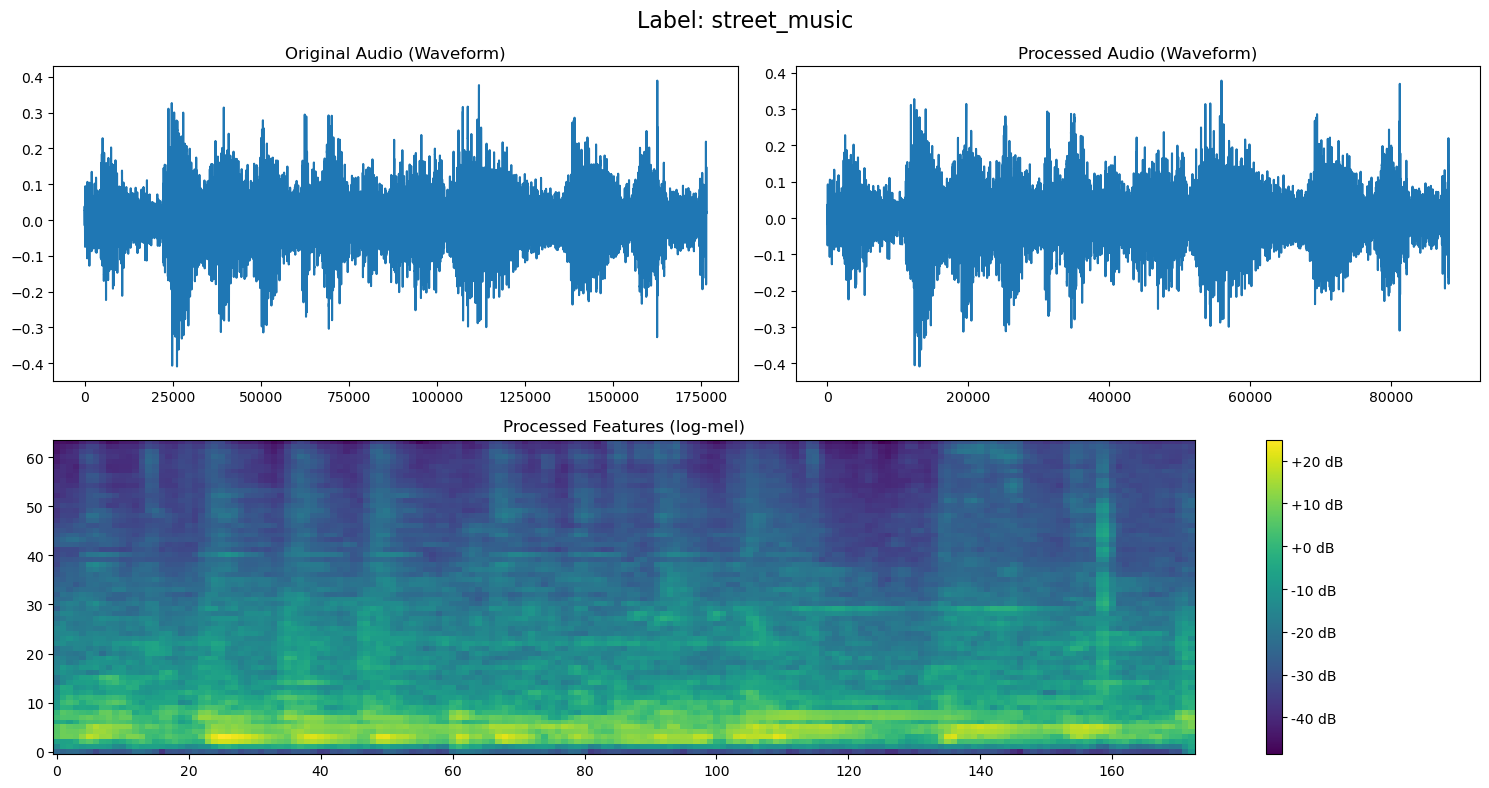

In [10]:
preview_preprocessing(class_id=2)
preview_preprocessing(class_id=4)
preview_preprocessing(class_id=9)

## Criação dos channels

Resta-nos portanto validar a aplicação dos filtros. Escolhemos um clipe com label `street_music`, perfeito para o efeito por ter componente melódica e componente percursiva 

Features shape: (5, 64, 173)


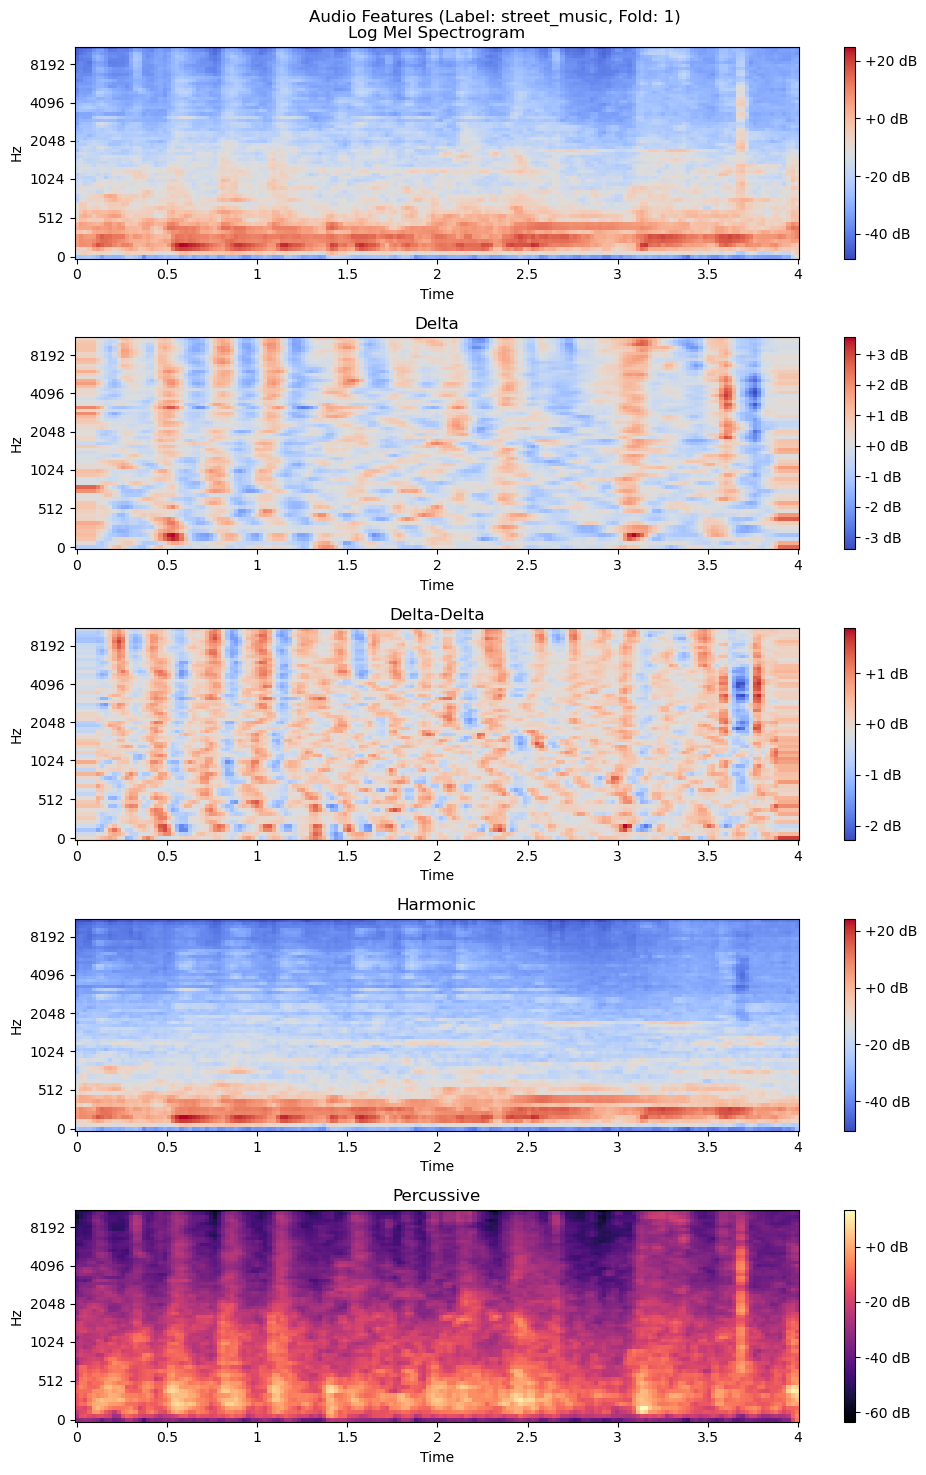

In [8]:
dl = Dataloader(dataset_path, preprocessing=AudioPreprocessor(sample_rate=22050, to_mono=True))
street_music_example_id = 18
features, fold, class_id = dl[street_music_example_id]
print(f"Features shape: {features.shape}")

label = dl.get_label_mapping()[class_id]
dl.preprocessing.plot_all_channels(features, fold, label)

Como podemos observar, as componentes da música original (no primeiro espectro) estão muito mais percetíveis após aplicação do HPSS, visto que conseguimos facilmente identificar, no ultimo espectro, as colunas verticais que representam a percussão da música.

## Análise t-SNE

Num qualquer pré-processamento, o objetivo final é aumentar a separabilidade das diferentes classes. Assim, no sentido de avaliarmos a utilidade do **espectro log-mel**, conduzamos uma análise de t-SNE, utilizando uma amostra de 1000 clipes (aproximadamente 1/8 do dataset).

Initializing Dataloader and Preprocessor...
Processing 1000 clips for analysis...
Features matrix shape: (1000, 11072)
Raw Audio matrix shape: (1000, 88200)
Running t-SNE on Raw Audio...
Features matrix shape: (1000, 11072)
Raw Audio matrix shape: (1000, 88200)
Running t-SNE on Raw Audio...
Running t-SNE on Features...
Running t-SNE on Features...


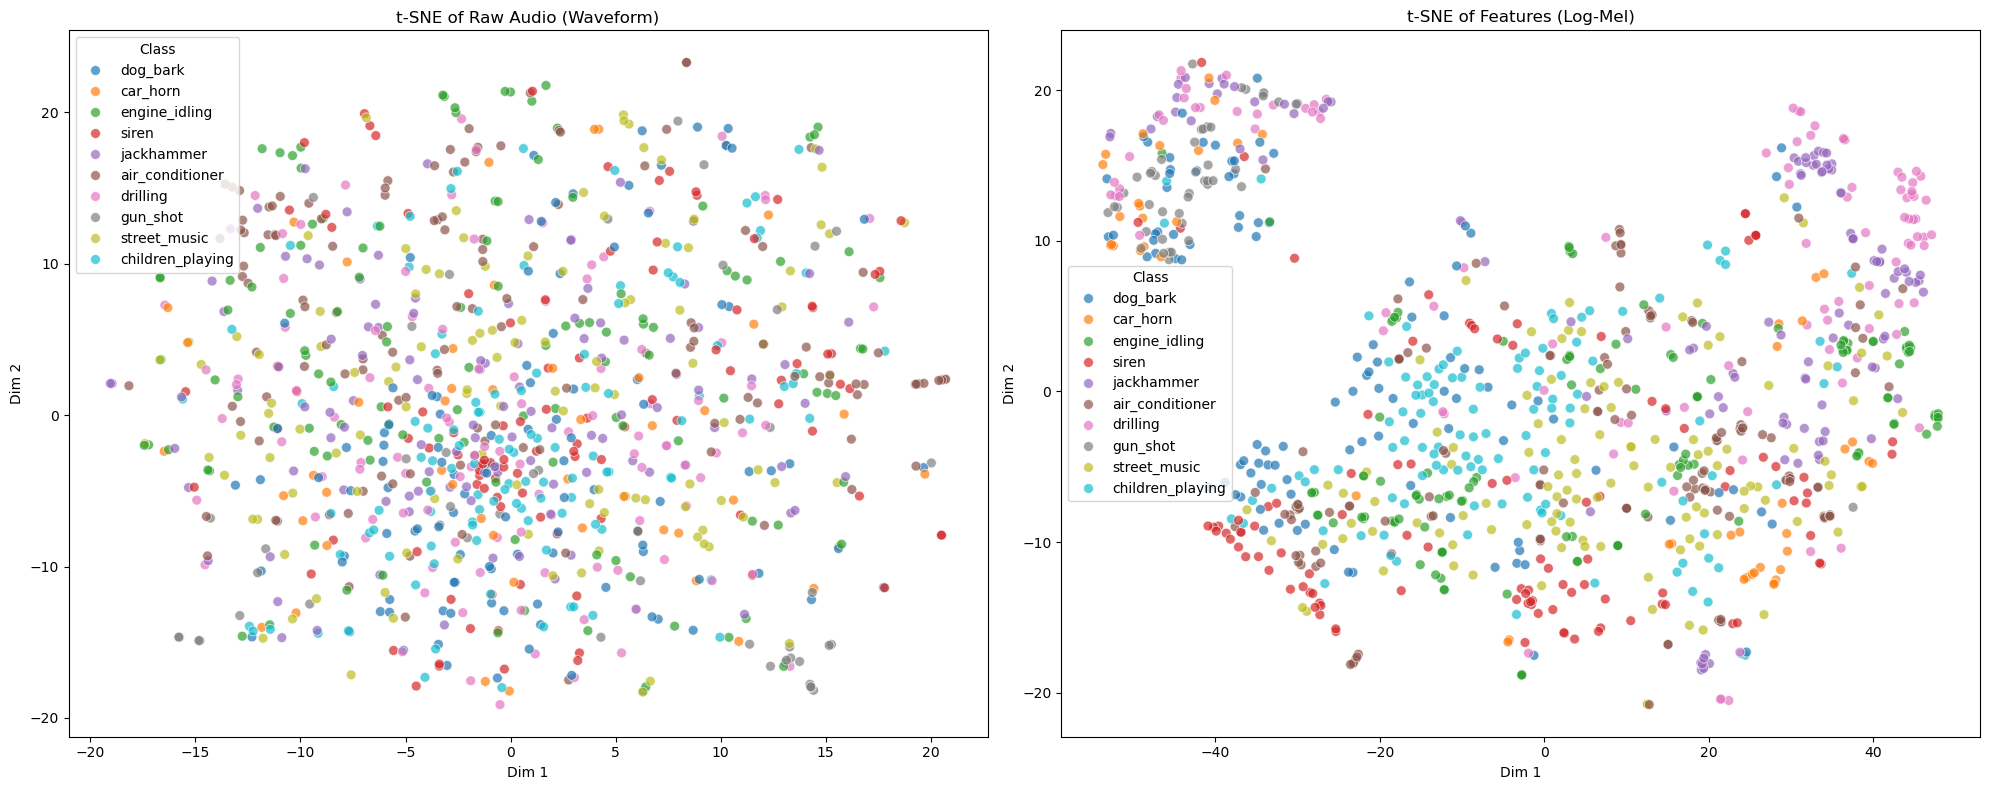

In [11]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import random
import os

def main():
    # Configurações
    NUM_SAMPLES = 1000
    SEED = 42
    DATASET_PATH = r"E:\deep-learning-urban-sound-data\datasets"

    print("Initializing Dataloader and Preprocessor...")
    # Inicializa o preprocessador
    preprocessor = AudioPreprocessor(sample_rate=22050, to_mono=True)

    # Inicializa o dataloader
    if not os.path.exists(DATASET_PATH):
        print(f"Dataset path not found: {DATASET_PATH}")
        return

    dl = Dataloader(DATASET_PATH)

    # Obter todos os clip IDs e selecionar uma amostra aleatória
    all_clip_ids = list(dl.all_clips.keys())
    random.seed(SEED)
    
    # Garantir que não pedimos mais amostras do que existem
    num_to_sample = min(NUM_SAMPLES, len(all_clip_ids))
    selected_clips = random.sample(range(len(dl)), num_to_sample)

    features_list = []
    raw_audio_list = []
    labels_list = []
    label_mapping = dl.get_label_mapping()

    print(f"Processing {num_to_sample} clips for analysis...")

    for idx, i in enumerate(selected_clips):
        # Update: Access clip directly from all_clips using clip_ids
        # because dl[i] now returns (audio, fold, label)
        clip_id = dl.clip_ids[i]
        clip = dl.all_clips[clip_id]
        
        # Processar o clipe
        try:
            # 1. Obter áudio "bruto" (apenas normalizado em tamanho/sr para poder entrar no PCA)
            # Precisamos fazer isso manualmente pois o process_clip faz tudo de uma vez
            audio, original_sr = clip.audio
            audio = preprocessor.monorize_audio(audio)
            audio = preprocessor.resample_audio(audio, original_sr)
            audio_raw = preprocessor.zero_pad_audio(audio)
            
            # 2. Extrair features (Log-Mel Spectrogram)
            feat = preprocessor._extract_log_mel(audio_raw)
            
            # Flatten das features para o t-SNE
            feat_flattened = feat.flatten()
            
            features_list.append(feat_flattened)
            raw_audio_list.append(audio_raw)
            labels_list.append(label_mapping[clip.class_id])
            
        except Exception as e:
            print(f"Error processing clip {clip_id}: {e}")

        #if (idx + 1) % 100 == 0:
        #    print(f"Processed {idx + 1}/{num_to_sample}")

    X_features = np.array(features_list)
    X_raw = np.array(raw_audio_list)
    y = np.array(labels_list)

    print(f"Features matrix shape: {X_features.shape}")
    print(f"Raw Audio matrix shape: {X_raw.shape}")

    # Configurar plot
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # --- 1. t-SNE on Raw Audio ---
    print("Running t-SNE on Raw Audio...")
    # Raw audio is too high dim (88k+) for direct t-SNE. 
    # We use PCA first to reduce to 50 components, then t-SNE.
    pca_reduce = PCA(n_components=50, random_state=SEED)
    X_raw_reduced = pca_reduce.fit_transform(X_raw)
    
    tsne_raw = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
    X_tsne_raw = tsne_raw.fit_transform(X_raw_reduced)

    df_raw = pd.DataFrame(X_tsne_raw, columns=['Dim 1', 'Dim 2'])
    df_raw['Label'] = y

    sns.scatterplot(
        data=df_raw,
        x='Dim 1',
        y='Dim 2',
        hue='Label',
        palette='tab10',
        alpha=0.7,
        s=50,
        ax=axes[0]
    )
    axes[0].set_title('t-SNE of Raw Audio (Waveform)')
    axes[0].legend(title='Class')

    # --- 2. t-SNE on Features ---
    print("Running t-SNE on Features...")
    tsne_features = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
    X_tsne_features = tsne_features.fit_transform(X_features)

    df_features = pd.DataFrame(X_tsne_features, columns=['Dim 1', 'Dim 2'])
    df_features['Label'] = y

    sns.scatterplot(
        data=df_features,
        x='Dim 1',
        y='Dim 2',
        hue='Label',
        palette='tab10',
        alpha=0.7,
        s=50,
        ax=axes[1]
    )
    # Update: Removed extraction_method as it was removed from Preprocessor
    axes[1].set_title(f't-SNE of Features (Log-Mel)')
    axes[1].legend(title='Class')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Podemos ver assim os dados sem (à esquerda) e com (à direita) pré-processamento. É claro que no caso sem pré-processamento, a distribuição dos audios é praticamente aleatória em todos os labels. Isto pode dever-se ao facto de mesmo áudios identicos, quando atrasados ou adiantados 1ms, produzirem vetores completamente diferentes, ocupando portanto espaços também diferentes.

Já no caso com pré-processamento conseguimos ver padrões claros. Para além de certos labels dominarem determinadas regiões (como o `drilling` no canto superior direito), vemos ainda um cluster muito definido no canto superior esquerdo. Algo interessante a apontar é que esse mesmo cluster contém apenas "sons percursivos", isto é, sons repentinos e que acabam rapidamente, contendo portanto pouquíssimas instâncias de labels como `street_music`, `children_playing` e `air_conditioner`.

Concluimos, portanto, que o pré-processamento foi bem sucedido, e prevemos que irá impactar positivamente a classificação futura.